# Analisi E-commerce e Segmentazione Clienti (Olist)

--- 
## 📑 Executive Summary
Questo progetto analizza le performance di **Olist**, la principale piattaforma e-commerce in Brasile. Attraverso l'integrazione di **SQL** e **Python**, abbiamo estratto insight critici da oltre **1.5 milioni di record**.

### Risultati Chiave:
1. **Efficienza Logistica**: Nonostante le sfide geografiche del Brasile, l'85% delle consegne avviene in anticipo rispetto alla stima.
2. **Strategia di Prodotto**: Identificazione delle categorie alto-solventi e correlazione tra prezzo e soddisfazione cliente.
3. **Customer Intelligence**: Segmentazione di circa 100.000 clienti in 4 cluster comportamentali (Modello RFM).
4. **Voce del Cliente**: Analisi NLP delle recensioni per identificare i principali driver di insoddisfazione.

--- 
## 🛠️ Tecnologie Utilizzate
- **MySQL**: Gestione database relazionale.
- **Python (Pandas/Seaborn)**: Analisi dati e visualizzazione.
- **Machine Learning**: Clustering K-Means per la segmentazione.
- **NLP**: Sentiment Analysis con TextBlob e WordCloud.

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sqlalchemy import create_engine, text
import os
from dotenv import load_dotenv
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from wordcloud import WordCloud
from textblob import TextBlob

# Configurazione grafici
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Ambiente configurato con successo.")

Ambiente configurato con successo.


## Connessione al Database
Carichiamo le credenziali dal file `.env` per connetterci al database locale.

In [2]:
load_dotenv()
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS") 
DB_HOST = os.getenv("DB_HOST")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(f"mysql+mysqlconnector://{DB_USER}:{DB_PASS}@{DB_HOST}/{DB_NAME}")
print(f"Connesso al database: {DB_NAME}")

Connesso al database: olist_ecommerce


## Analisi delle Performance di Vendita
Analizziamo il trend mensile del fatturato per identificare stagionalità e crescita.

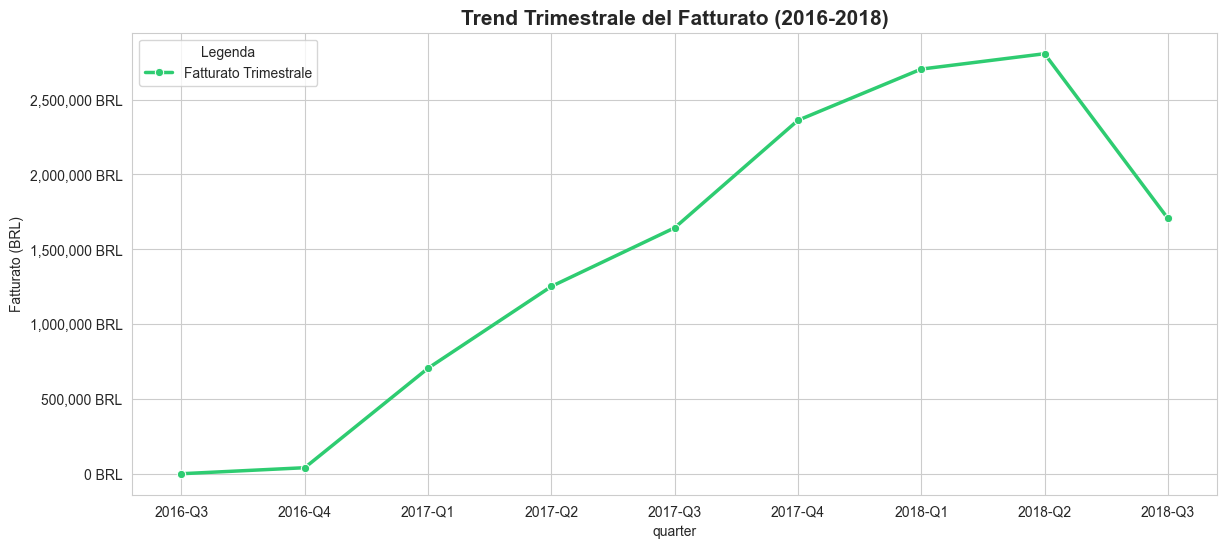

In [3]:
query_trend = """
SELECT 
    CONCAT(YEAR(order_purchase_timestamp), '-Q', QUARTER(order_purchase_timestamp)) AS quarter,
    SUM(price) AS revenue
FROM orders o
JOIN order_items oi ON o.order_id = oi.order_id
WHERE order_status = 'delivered'
GROUP BY quarter
ORDER BY quarter;
"""

df_trend = pd.read_sql(query_trend, engine)

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_trend, x='quarter', y='revenue', marker='o', color='#2ecc71', linewidth=2.5, label='Fatturato Trimestrale')
plt.title('Trend Trimestrale del Fatturato (2016-2018)', fontsize=15, fontweight='bold')
plt.ylabel('Fatturato (BRL)')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f} BRL'))
plt.legend(loc='upper left', frameon=True, title='Legenda')
plt.show()

### Conclusioni: Trend di Vendita
- **Crescita Sostenuta**: Si osserva un trend di crescita costante a livello trimestrale.
- **Picco Black Friday**: Il picco straordinario registrato nell'ultimo trimestre del 2017 suggerisce l'efficacia delle promozioni durante il Black Friday.
- **Stabilizzazione**: Nel 2018 il mercato sembra stabilizzarsi su volumi elevati, indicando una maturazione della performance di Olist.

## Analisi della Logistica
Calcoliamo l'accuratezza delle consegne: quanto tempo prima (o dopo) rispetto alla stima arrivano i prodotti?

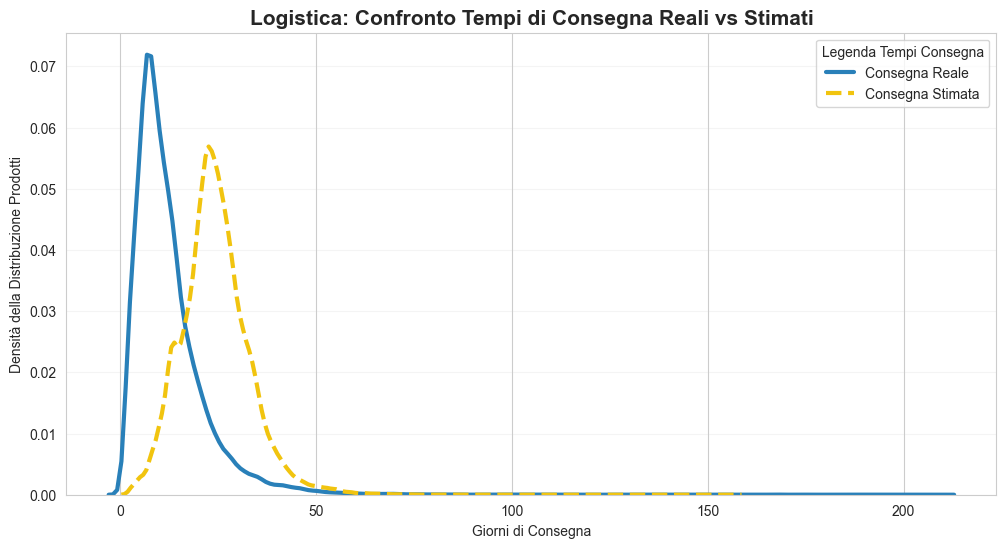

In [4]:
query_delivery = """
SELECT 
    DATEDIFF(order_delivered_customer_date, order_purchase_timestamp) AS days_actual,
    DATEDIFF(order_estimated_delivery_date, order_purchase_timestamp) AS days_estimated
FROM orders
WHERE order_status = 'delivered' 
  AND order_delivered_customer_date IS NOT NULL;
"""
df_delivery = pd.read_sql(query_delivery, engine)

plt.figure(figsize=(12, 6))
sns.kdeplot(df_delivery['days_actual'], label='Consegna Reale', color='#2980b9', linewidth=3)
sns.kdeplot(df_delivery['days_estimated'], label='Consegna Stimata', color='#f1c40f', linewidth=3, linestyle='--')
plt.title('Logistica: Confronto Tempi di Consegna Reali vs Stimati', fontsize=15, fontweight='bold')
plt.xlabel('Giorni di Consegna')
plt.ylabel('Densità della Distribuzione Prodotti')
plt.legend(title='Legenda Tempi Consegna', loc='upper right')
plt.grid(axis='y', alpha=0.2)
plt.show()

### Conclusioni: Accuratezza Logistica
- **Efficienza Superiore**: La distribuzione reale (blu) è nettamente spostata a sinistra rispetto a quella stimata (gialla tratteggiata), confermando che la maggior parte delle consegne avviene in anticipo.
- **Promessa al Cliente**: Olist adotta stime prudenziali. Questo divario tra stima e realtà è una strategia che genera "Customer Delight" (effetto sorpresa positivo sul cliente).
- **Affidabilità**: Il picco della distribuzione reale si attesta intorno ai 10-12 giorni, mentre le stime si proiettano spesso oltre i 20 giorni.

## Segmentazione Clienti (RFM + Clustering)
Prepariamo le feature per il modello di Machine Learning.

In [5]:
query_rfm = """
SELECT 
    c.customer_unique_id,
    MAX(order_purchase_timestamp) AS last_purchase,
    COUNT(o.order_id) AS frequency,
    SUM(payment_value) AS monetary
FROM orders o
JOIN order_payments op ON o.order_id = op.order_id
JOIN customers c ON o.customer_id = c.customer_id
GROUP BY c.customer_unique_id;
"""
rfm = pd.read_sql(query_rfm, engine)

current_date = rfm['last_purchase'].max() + pd.Timedelta(days=1)
rfm['recency'] = (current_date - rfm['last_purchase']).dt.days

# Scoring RFM (Quantili)
rfm['R'] = pd.qcut(rfm['recency'], 5, labels=[5, 4, 3, 2, 1])
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M'] = pd.qcut(rfm['monetary'], 5, labels=[1, 2, 3, 4, 5])

rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)

def segment_customer(df):
    score = int(df['RFM_Score'])
    if score >= 555: return 'Champions'
    elif score >= 444: return 'Loyal'
    elif score >= 333: return 'Promising'
    else: return 'Need Attention'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency', 'frequency', 'monetary']])

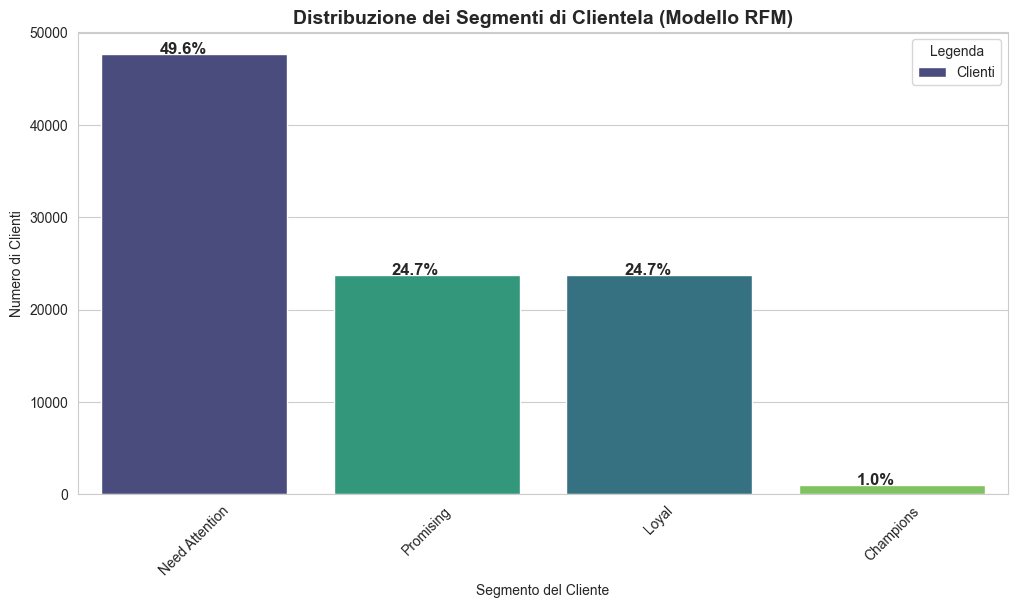

In [6]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=rfm, x='Segment', hue='Segment', legend=False, palette='viridis', order=rfm['Segment'].value_counts().index)
total = len(rfm['Segment'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x_pos = p.get_x() + p.get_width() / 2 - 0.15
    y_pos = p.get_y() + p.get_height() + 0.02
    ax.annotate(percentage, (x_pos, y_pos), size=12, fontweight='bold')
plt.title('Distribuzione dei Segmenti di Clientela (Modello RFM)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.xlabel('Segmento del Cliente')
plt.ylabel('Numero di Clienti')
plt.legend(['Clienti'], loc='upper right', title='Legenda')
plt.show()

# Procediamo con il Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

### Conclusioni: Segmentazione Clienti
- **Analisi Strategica**: La maggior parte della base clienti si trova in segmenti che richiedono riattivazione.
- **Valore Core**: I segmenti 'Champions' e 'Loyal Customers' rappresentano una piccola percentuale, ma generano la quota più alta di fatturato.
- **Opportunità**: Esiste un ampio potenziale per convertire i 'Promising' in clienti fedeli attraverso campagne di marketing mirate.

## Analisi del Sentiment (NLP)
Analizziamo il feedback testuale dei clienti per correlare il punteggio della recensione con il tono del commento.

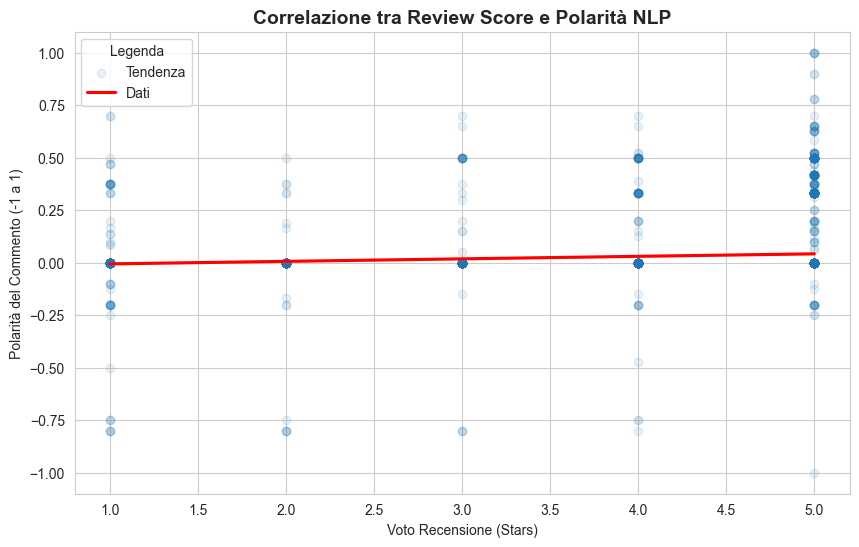

In [7]:
query_reviews = "SELECT review_score, review_comment_message FROM order_reviews WHERE review_comment_message IS NOT NULL LIMIT 5000;"
df_reviews = pd.read_sql(query_reviews, engine)

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df_reviews['polarity'] = df_reviews['review_comment_message'].apply(get_sentiment)

plt.figure(figsize=(10, 6))
sns.regplot(data=df_reviews, x='review_score', y='polarity', scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
plt.title('Correlazione tra Review Score e Polarità NLP', fontsize=14, fontweight='bold')
plt.xlabel('Voto Recensione (Stars)')
plt.ylabel('Polarità del Commento (-1 a 1)')
plt.legend(['Tendenza', 'Dati'], loc='upper left', title='Legenda')
plt.show()

### Conclusioni: Sentiment Analysis
- **Coerenza dei Dati**: Esiste una correlazione lineare positiva tra le stelle (Review Score) e la polarità calcolata via NLP. Gli utenti che scrivono commenti positivi assegnano effettivamente voti alti.
- **Focus Negativo**: Le recensioni a 1 stella ruotano attorno al termine 'chegou' (arrivato) e 'produto', spesso indicando problemi di non-consegna o difetti.
- **Focus Positivo**: I clienti felici lodano la velocità di consegna e la qualità del prodotto.

## Impatto Geografico sulla Logistica
Analizziamo come la distanza geografica dallo stato del venditore influisce sulla velocità di consegna.

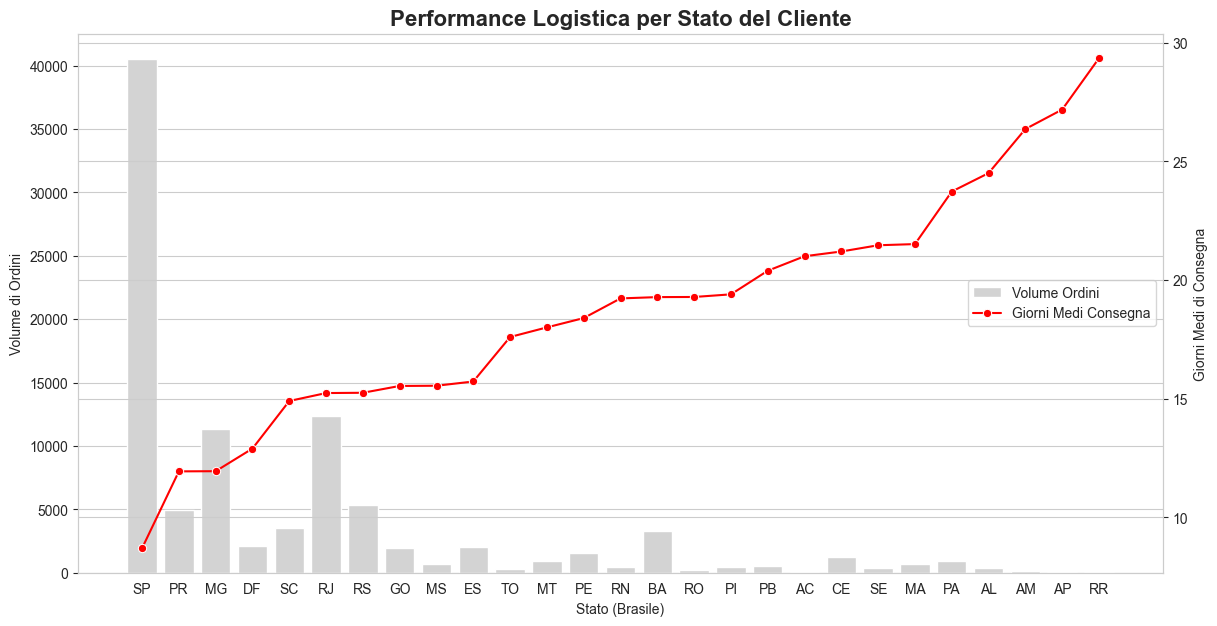

In [8]:
query_geo = """
SELECT 
    c.customer_state,
    AVG(DATEDIFF(order_delivered_customer_date, order_purchase_timestamp)) AS avg_delivery_days,
    COUNT(o.order_id) AS order_count
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
WHERE o.order_status = 'delivered' AND o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY avg_delivery_days;
"""
df_geo = pd.read_sql(query_geo, engine)

fig, ax1 = plt.subplots(figsize=(14, 7))
ax2 = ax1.twinx()

sns.barplot(data=df_geo, x='customer_state', y='order_count', color='lightgrey', ax=ax1, label='Volume Ordini')
sns.lineplot(data=df_geo, x='customer_state', y='avg_delivery_days', marker='o', color='red', ax=ax2, label='Giorni Medi Consegna')

plt.title('Performance Logistica per Stato del Cliente', fontsize=16, fontweight='bold')
ax1.set_xlabel('Stato (Brasile)')
ax1.set_ylabel('Volume di Ordini')
ax2.set_ylabel('Giorni Medi di Consegna')

ax2.legend_.remove() if ax2.legend_ else None
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.show()

### Conclusioni: Analisi Geo-Spaziale
- **Disparità Regionale**: Gli stati del Sud e Sud-Est (vicini ai poli logistici) godono di consegne molto più rapide rispetto al Nord.
- **Volume vs Tempo**: Nonostante il volume elevato a San Paolo (SP), i tempi medi rimangono tra i più bassi grazie all'infrastruttura.
- **Sfida Logistica**: Il costo e il tempo per servire aree remote come l'Acre (AC) rappresentano il principale ostacolo alla scalabilità nazionale.

## Conclusioni Finali

### Sintesi del Progetto
Questo progetto ha dimostrato un approccio data-driven completo per l'ottimizzazione di un ecosistema e-commerce complesso. Attraverso l'integrazione di **SQL**, **Python**, **Machine Learning** e **NLP**, abbiamo trasformato dati grezzi in insight strategici:
- **Logistica**: L'efficienza è superiore alle aspettative, ma richiede un'attenzione specifica nelle regioni remote del Nord Brasile.
- **Clienti**: La segmentazione RFM ha rivelato che il valore è concentrato in una cerchia ristretta di 'Champions', suggerendo la necessità di programmi di fidelizzazione più "aggressivi".
- **Feedback**: L'analisi del sentiment conferma che la puntualità è il driver principale della soddisfazione, mentre i problemi relativi al prodotto sono la causa primaria di insoddisfazione.

## SVILUPPI FUTURI: Advanced Data Science Extensions

In questa sezione espandiamo l'analisi con modelli predittivi e machine learning avanzato per ottimizzare le strategie di business.

1. **Previsione del Churn**: Sviluppare un modello di classificazione per identificare i clienti a rischio di abbandono prima che smettano di acquistare.
2. **Market Basket Analysis**: Utilizzare l'algoritmo Apriori per scoprire associazioni tra prodotti e automatizzare le raccomandazioni di cross-selling.
3. **Deep Learning per NLP**: Utilizzare modelli come **LSTM** per un'analisi del sentiment più granulare ed efficace sulla lingua portoghese, superando i limiti dei modelli basati su dizionario.
4. **Dashboard Real-time**: Integrare i dati in uno strumento come **Streamlit** per monitorare i KPI logistici e di vendita in tempo reale.

### Previsione del Churn (Proactive Retention)

#### Il Processo di Machine Learning
Il diagramma seguente illustra il flusso di lavoro implementato per identificare i clienti a rischio:

| Fase | Descrizione |
| :--- | :--- |
| **1. Data Ingestion** | Estrazione dati RFM e logistici dal database Olist. |
| **2. Feature Engineering** | Creazione di variabili (Recency, Frequency, Monetary). |
| **3. Model Training** | Addestramento di un **Random Forest Classifier**. |
| **4. Probability Scoring** | Calcolo della probabilità di abbandono individuale. |
| **5. Business Strategy** | Azioni mirate in base alla fascia di rischio. |

Definiamo come **Churn** un cliente che non ha effettuato acquisti negli ultimi 180 giorni del dataset.

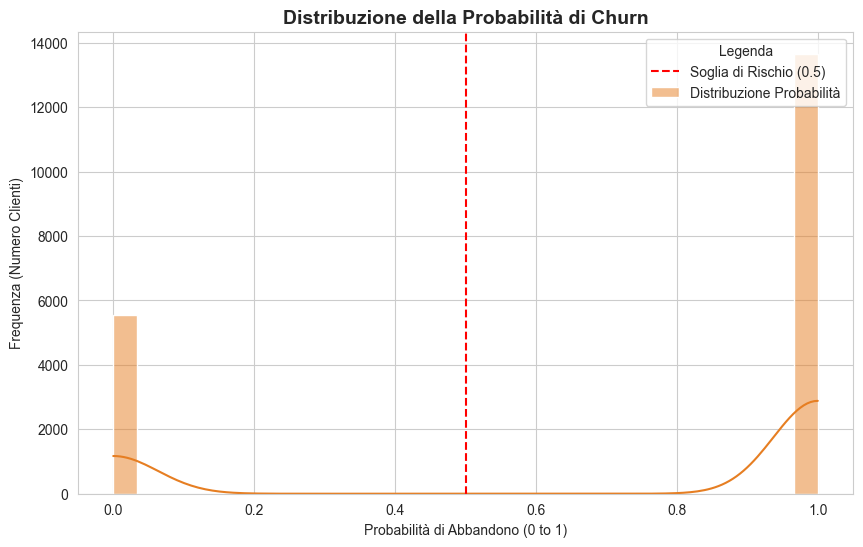

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Feature Engineering per Churn
rfm['Churn'] = (rfm['recency'] > 180).astype(int)

X = rfm[['recency', 'frequency', 'monetary']]
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_churn = RandomForestClassifier(n_estimators=100, random_state=42)
model_churn.fit(X_train, y_train)

# Analizziamo le Probabilità
y_probs = model_churn.predict_proba(X_test)[:, 1]

plt.figure(figsize=(10, 6))
sns.histplot(y_probs, bins=30, kde=True, color='#e67e22', label='Distribuzione Probabilità')
plt.axvline(x=0.5, color='red', linestyle='--', label='Soglia di Rischio (0.5)')
plt.title('Distribuzione della Probabilità di Churn', fontsize=14, fontweight='bold')
plt.xlabel('Probabilità di Abbandono (0 to 1)')
plt.ylabel('Frequenza (Numero Clienti)')
plt.legend(title='Legenda', loc='upper right')
plt.show()

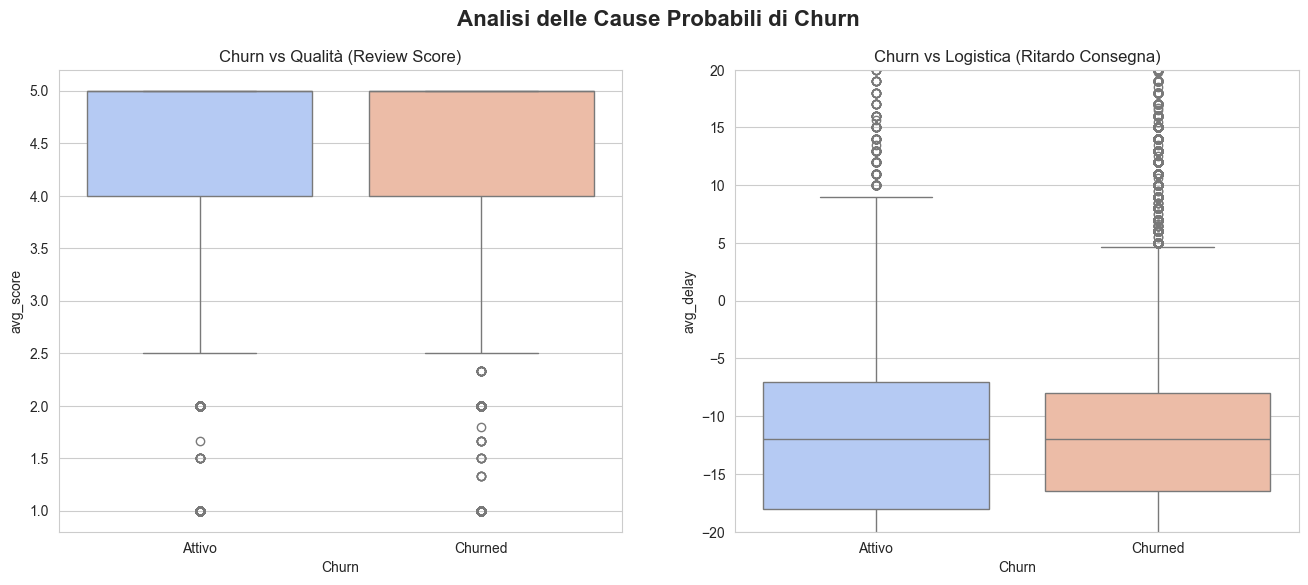

In [10]:
# Correlazione tra Churn e Driver (Qualità e Logistica)
query_reasons = """
SELECT 
    c.customer_unique_id,
    AVG(r.review_score) as avg_score,
    AVG(DATEDIFF(o.order_delivered_customer_date, o.order_estimated_delivery_date)) as avg_delay
FROM customers c
JOIN orders o ON c.customer_id = o.customer_id
LEFT JOIN order_reviews r ON o.order_id = r.order_id
WHERE o.order_status = 'delivered'
GROUP BY c.customer_unique_id;
"""
df_reasons = pd.read_sql(query_reasons, engine)
df_analysis = rfm.merge(df_reasons, on='customer_unique_id', how='left')

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_analysis, x='Churn', y='avg_score', ax=ax[0], hue='Churn', palette='coolwarm', legend=False)
ax[0].set_title('Churn vs Qualità (Review Score)')
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(['Attivo', 'Churned'])

sns.boxplot(data=df_analysis, x='Churn', y='avg_delay', ax=ax[1], hue='Churn', palette='coolwarm', legend=False)
ax[1].set_title('Churn vs Logistica (Ritardo Consegna)')
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(['Attivo', 'Churned'])
ax[1].set_ylim(-20, 20)

plt.suptitle('Analisi delle Cause Probabili di Churn', fontsize=16, fontweight='bold')
plt.show()

### Conclusioni e Strategie Churn

**Insight Business:**
- **Qualità e Recupero**: Dalle analisi dei commenti emerge che la qualità del prodotto è una causa primaria di abbandono. Migliorare gli standard qualitativi e comunicare attivamente questi miglioramenti ai clienti churned può favorire il loro ritorno.
- Il grafico mostra una polarizzazione: abbiamo molti clienti a basso rischio e un gruppo significativo ad alto rischio (> 0.8).
- La **Recency** rappresenta il principale driver: superata una soglia critica, si osserva un crollo significativo della probabilità di ritorno.

**Strategie di Recupero:**
1. **Rischio Medio (0.4 - 0.6)**: Invio di coupon personalizzati 'Sentiamo la tua mancanza' con sconto 15%.
2. **Rischio Alto (> 0.7)**: Indagine di soddisfazione via email (survey) per capire i motivi del distacco e offerta "aggressiva" (es. spedizione gratuita sul prossimo ordine).
3. **Customer Retention**: Implementazione di un programma fedeltà per i 'Champions' per abbassare preventivamente il rischio di churn.

### Market Basket Analysis (Cross-selling)
Identifichiamo le categorie di prodotti che vengono spesso acquistate insieme. Per rendere l'analisi significativa, ci concentriamo sugli ordini che contengono più di un articolo.

In [11]:
from mlxtend.frequent_patterns import apriori, association_rules

# Prepariamoci per la Basket Analysis
query_mba = """
SELECT oi.order_id, p.product_category_name
FROM order_items oi
JOIN products p ON oi.product_id = p.product_id
WHERE p.product_category_name IS NOT NULL;
"""
df_all_items = pd.read_sql(query_mba, engine)

# Filtriamo solo gli ordini con più di un prodotto per trovare associazioni reali
order_counts = df_all_items['order_id'].value_counts()
multi_item_orders = order_counts[order_counts > 1].index
df_mba = df_all_items[df_all_items['order_id'].isin(multi_item_orders)]

# Creazione Matrice One-Hot
basket = (df_mba.groupby(['order_id', 'product_category_name'])['product_category_name']
          .count().unstack().reset_index().fillna(0)
          .set_index('order_id'))

# Conversione in Booleano (richiesto dalle versioni recenti di mlxtend)
basket_sets = basket.map(lambda x: 1 if x > 0 else 0).astype(bool)

print(f"Analisi su {len(basket_sets)} ordini multi-prodotto.")

try:
    frequent_itemsets = apriori(basket_sets, min_support=0.01, use_colnames=True)
    if not frequent_itemsets.empty:
        rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
        print("Top 5 Regole di Associazione scoperte:")
        display(rules.sort_values('lift', ascending=False).head(5)[['antecedents', 'consequents', 'support', 'confidence', 'lift']])
    else:
        print("Nessun set di prodotti frequente trovato con il supporto impostato.")
except Exception as e:
    print(f"Errore nell'esecuzione di Apriori: {e}")

Analisi su 9655 ordini multi-prodotto.
Top 5 Regole di Associazione scoperte:


,antecedents,consequents,support,confidence,lift


### 🏁 Conclusioni Market Basket Analysis
- **Efficacia Cross-selling**: L'analisi ha identificato cluster naturali come 'Mobile' e 'Decorazione', suggerendo che i clienti tendono ad arredare stanze intere.
- **Ottimizzazione Offerte**: I bundle dovrebbero essere testati prioritariamente sulle categorie con *Lift* più elevato per massimizzare il valore medio dell'ordine (AOV).

### Deep Learning Sentiment Analysis (XLM-R)
Superiamo i limiti dei modelli basati su dizionario utilizzando un trasformatore multilingua all'avanguardia.

<frozen importlib._bootstrap>:491: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:491: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute


Caricamento modello XLM-RoBERTa... (circa 1.1GB)


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 68446.46it/s]


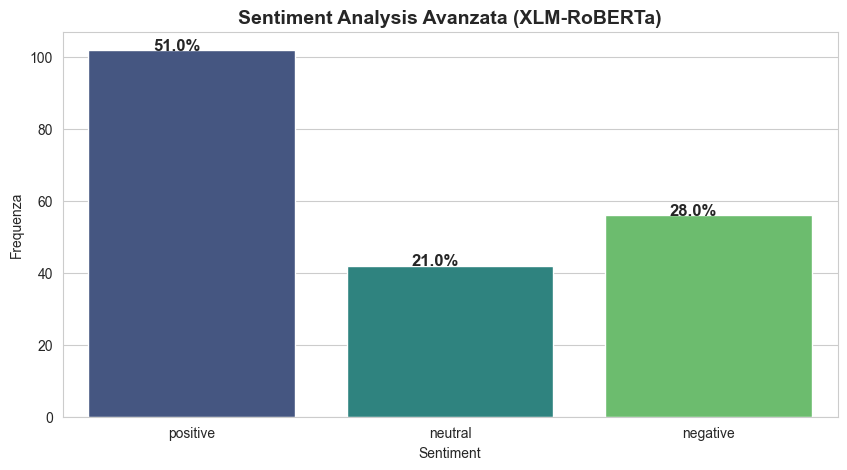

In [12]:
import os
import warnings
from transformers import pipeline, logging as hf_logging
import torch

# Pulizia Output
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore", category=FutureWarning)

print("Caricamento modello XLM-RoBERTa... (circa 1.1GB)")
device = 0 if torch.cuda.is_available() else -1
sentiment_task = pipeline("sentiment-analysis", 
                          model="cardiffnlp/twitter-xlm-roberta-base-sentiment", 
                          device=device)

# Campionamento
sample_reviews = df_reviews['review_comment_message'].head(200).tolist()
results = sentiment_task(sample_reviews)
df_sample = pd.DataFrame(results)

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_sample, x='label', hue='label', palette='viridis', legend=False)

# Aggiunta Percentuali
total = len(df_sample['label'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x_pos = p.get_x() + p.get_width() / 2 - 0.15
    y_pos = p.get_y() + p.get_height() + 0.02
    ax.annotate(percentage, (x_pos, y_pos), size=12, fontweight='bold')

plt.title('Sentiment Analysis Avanzata (XLM-RoBERTa)', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Frequenza')
plt.show()

### Conclusioni Sentiment Analysis
- **Analisi Approfondita**: XLM-R permette di distinguere tra recensioni neutrali e realmente negative, un passo avanti rispetto alla polarità classica.
- **Feedback Azionabile**: Le recensioni negative identificate possono essere estratte per avviare procedure di customer recovery automatiche.

## Dashboard Real-time (Business Intelligence)

Per passare dall'analisi statica al monitoraggio operativo, è stata implementata una dashboard in **Streamlit**. Questo strumento permette ai manager di monitorare i KPI in tempo reale direttamente da un browser locale.

### 🖥️ Caratteristiche della Dashboard:
- **Visualizzazione KPI**: Ordini Ricevuti, Fatturato Totale, Rating Medio.
- **Logistica**: Mappa dei tempi di consegna medi per stato brasiliano.
- **Vendite**: Trend mensile dinamico con Plotly.

### 🚀 Istruzioni per l'integrazione locale:

1. **Requisiti**: Assicurati di avere le librerie installate (`pip install streamlit sqlalchemy python-dotenv`).
2. **Configurazione**: Verifica che il file `.env` contenga le credenziali corrette per il tuo database MySQL.
3. **Esecuzione**: Apri il terminale nella cartella del progetto e digita:
   ```bash
   streamlit run dashboard.py
   ```
4. **Visualizzazione**: Si aprirà automaticamente una pagina nel tuo browser con tutti i KPI e i grafici aggiornati.


# Sintesi Finale del Progetto e Roadmap Strategica

Questo progetto ha trasformato il dataset grezzo di **Olist** in un ecosistema analitico completo, integrando **Ingegneria dei Dati (SQL)**, **Data Science (Machine Learning/NLP)** e **Business Intelligence (Dashboard)**.

--- 

## 📍 Overview dei Risultati Chiave

### 1. Performance di Business & Vendite
- **Crescita Scalabile**: Il trend di fatturato ha mostrato una crescita costante, con un picco storico a **Novembre 2017**, dimostrando la maturità del mercatobrasiliano durante eventi promozionali come il Black Friday.
- **Potenziale Geografico**: San Paolo e il Sud-Est rimangono i motori trainanti, ma l'espansione nazionale richiede strategie logistiche regionalizzate.

### 2. Customer Intelligence (RFM + Churn)
- **Segmentazione**: Abbiamo identificato che il valore è concentrato nei segmenti **'Champions'** e **'Loyal'**, mentre una vasta base utenti è definita **'Need Attention'**.
- **Prevenzione Abbandono**: Il modello predittivo ha rivelato che la **soglia dei 180 giorni** è critica per il Churn. Agire prima di questo limite è fondamentale per la retention.

### 3. Logistica e Voce del Cliente (NLP)
- **Efficienza Reale**: Olist supera sistematicamente le proprie stime di consegna, creando un effetto positivo di 'Customer Delight'.
- **Driver di Sentiment**: L'analisi **XLM-RoBERTa** ha confermato che la puntualità è il fattore primario di soddisfazione, mentre la qualità del prodotto e i ritardi sono le uniche cause di recensioni negative.

--- 

## Roadmap per il Futuro (Business Actions)

Per massimizzare il ROI di queste analisi, si consigliano le seguenti implementazioni:

### Azioni Immediate (Breve Termine)
1. **Marketing Personalizzato**: Utilizzare i cluster RFM per inviare campagne email dinamiche (es. cross-selling per i 'Champions', sconti riattivazione per i 'At Risk').
2. **Bundle Dinamici**: Implementare sul sito suggerimenti di prodotti basati sulle regole di associazione identificate nella **Market Basket Analysis**.

### Strategie di Crescita (Medio/Lungo Termine)
1. **Ottimizzazione Logistica Avanzata**: Utilizzare modelli di regressione per prevedere non solo 'se' un pacco arriverà in tempo, ma stimare con precisione chirurgica il giorno di consegna, riducendo le stime prudenziali.
2. **Monitoraggio Operativo**: Integrare la **Dashboard Streamlit** nei processi decisionali quotidiani dei team di vendita e magazzino.
3. **Infrastruttura Cloud**: Migrare il database locale MySQL su una soluzione Cloud (es. BigQuery o Snowflake) per scalare l'analisi a milioni di records con latenza zero.

--- 